In [1]:
import torch
import numpy as np
import time

import hockey.hockey_env as h_env

from sac.plots import *
from sac.utils import from_dict, SB3_PARAMS

In [2]:
env_name = "Shooting"
env = h_env.HockeyEnv(mode=h_env.Mode.TRAIN_SHOOTING)

In [ ]:
action_low = env.action_space.low[:4]
action_high = env.action_space.high[:4]
action_bounds = (action_low, action_high)

In [3]:
params = SB3_PARAMS
hidden_sizes = [256, 256]

In [4]:
random_seed = 0

In [5]:
if random_seed is not None:
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)

In [6]:
sac = from_dict(env=env, hidden_sizes=hidden_sizes, action_bounds=action_bounds, **params)

In [7]:
agent = sac
agent_name = "SAC"

In [8]:
filepath = f"./shooting/{agent_name}-{env_name}-{random_seed}"

In [9]:
scaling = np.asarray([ 1.0,  1.0 , 0.5, 4.0, 4.0, 4.0,  
            1.0,  1.0,  0.5, 4.0, 4.0, 4.0,  
            2.0, 2.0, 10.0, 10.0, 4.0 ,4.0])

In [91]:
env_name = "Shooting"
env = h_env.HockeyEnv(mode=h_env.Mode.TRAIN_SHOOTING)

In [92]:
for i in range(5):
    o, info = env.reset()
    o /= scaling
    env.render()
    
    for _ in range(1000):
        env.render()
        a1 = agent.act(o) # np.random.uniform(-1,1,4)
        # a1 = np.random.uniform(-1, 1, 4)
        a2 = [0,0.,0,0] 
        obs, r, d, t , info = env.step(np.hstack([a1,a2]))
        obs /= scaling
        agent.store_transition((o, a1, r, obs, d))
        o = obs
        # obs_agent2 = env.obs_agent_two()
        if d or t: break

In [93]:
env.close()

In [16]:
losses = []
rewards = []
env_name = "Shooting"
env = h_env.HockeyEnv(mode=h_env.Mode.TRAIN_SHOOTING)

In [83]:
max_timesteps = 1000
new_episodes = 500
log_interval = 10
train_interval = 20

In [84]:
agent.alpha = 0.01

In [85]:
for i in range(new_episodes):
    total_reward = 0
    o, info = env.reset()
    o /= scaling
    # env.render()

    for j in range(max_timesteps):
        # env.render()
        a1 = agent.act(o) # np.random.uniform(-1,1,4)
        a2 = [0,0.,0,0] 
        obs, r, d, t , info = env.step(np.hstack([a1,a2]))
        obs /= scaling
        agent.store_transition((o, a1, r, obs, d))
        if j % train_interval == 0:
            loss = agent.train()
            losses.append(loss)
        total_reward += r
        o = obs
        # obs_agent2 = env.obs_agent_two()
        if d or t: break
    
    rewards.append(total_reward)
    if (i+1) % 10 == 0:
        print(i+1, np.mean(rewards[-10:]))

10 5.4723457222239285
20 3.3918574746860997
30 3.115669067513498
40 2.765658228422391
50 3.3109679205398153
60 4.4997216453782425
70 4.597418591142957
80 5.631283433387114
90 -2.629928902881343
100 3.3948200976232856
110 -2.0159778959503596
120 6.355861559077645
130 3.0280235058894127
140 0.37554425902422717
150 0.5470168958935376
160 -1.9170016077432972
170 2.393265947594629
180 -2.3514833282503123
190 5.650765288798538
200 -2.085532175292253
210 0.5656969522121188
220 2.0417167004758014
230 -1.7907268635719908
240 2.4576572484594967
250 1.0449258138813462
260 -1.2647979051033793
270 6.219653715418436
280 0.24674105770129023
290 -0.5743333894614092
300 -3.98692195589461
310 -0.3587272501880451
320 -3.2583952360567467
330 -2.116402272709211
340 -1.7718811646666073
350 -2.2777736466572005
360 2.20434905468914
370 -5.528881349101178
380 2.3696677262557606
390 -3.516262633462162
400 1.2728762094312134
410 4.155600343372513
420 0.12253141442699897
430 4.758692243157922
440 1.78606920153623

In [94]:
print("########## Saving a checkpoint... ##########")
torch.save(agent.state(), f'{filepath}-{3000}.pth')

########## Saving a checkpoint... ##########


In [96]:
from sac.utils import save_statistics
save_statistics(filepath, rewards, [], losses)

In [86]:
plot_path = "shooting"

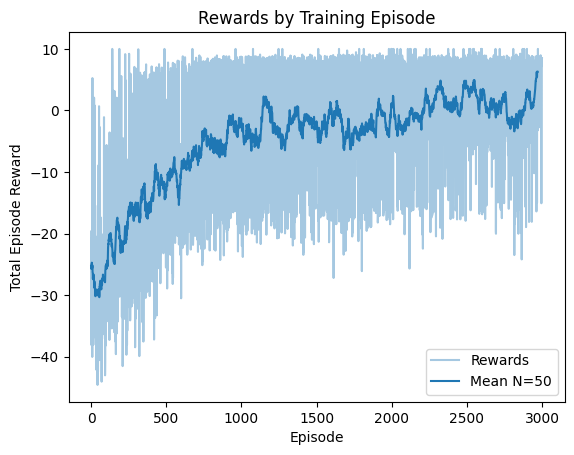

In [87]:
plot_rewards(rewards, plot_path, 30)

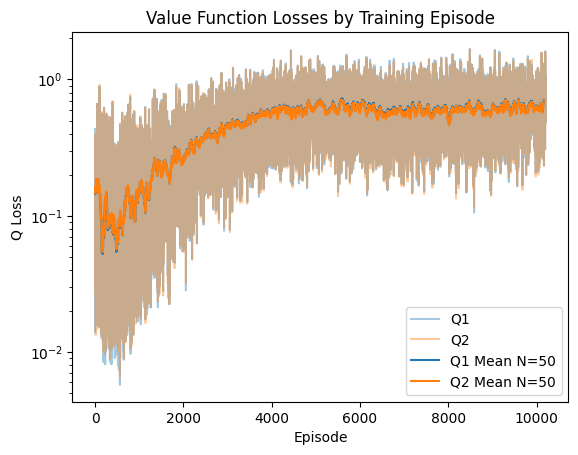

In [88]:
q_losses = np.asarray(losses)[:,0,:2]
plot_q(q_losses, plot_path)

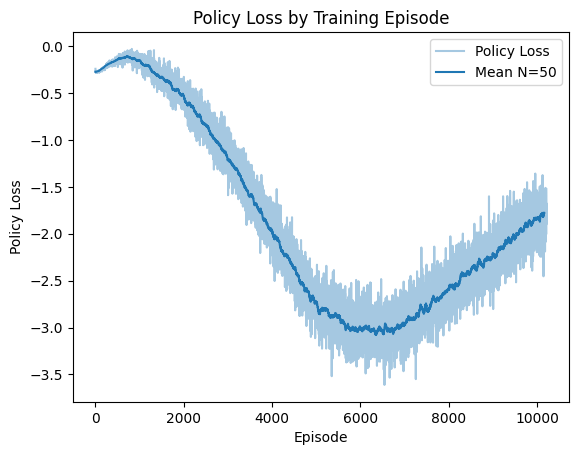

In [89]:
policy_loss = np.asarray(losses)[:,0,2]
plot_policy_loss(policy_loss, plot_path)

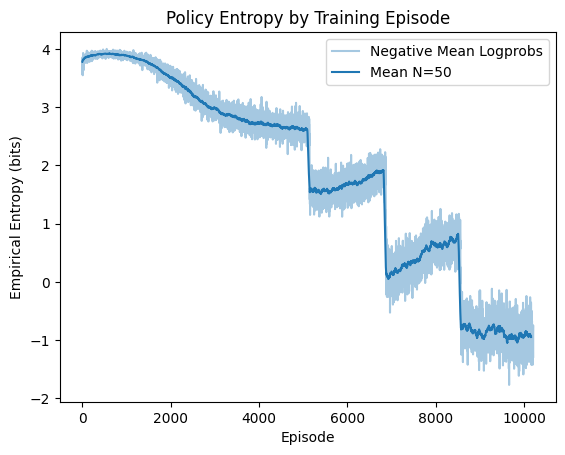

In [90]:
logprobs = np.asarray(losses)[:,0,-1]
plot_entropy(logprobs, plot_path)

In [48]:
o

array([-0.52528334,  2.87576818,  2.09319282, -0.01326284,  0.        ,
        0.45939553,  0.85257912,  1.34278488, -0.11732937,  0.01806555,
       -0.01471644,  0.28084534, -1.78445196,  1.1484015 , -2.39410248,
        0.50272269,  0.        ,  0.        ])

In [13]:
print(agent.policy.forward(torch.tensor(o[None]).float()))

(tensor([[-0.0788, -0.0185,  0.2728, -0.2147]], grad_fn=<SliceBackward0>), tensor([[-0.0787, -0.0098, -0.0780,  0.1784]], grad_fn=<ClampBackward1>))
